# Wildfire Dataset Final Report
STAT 301 April 18, 2026

G30: Statistically Significant

Alyson Kosek

Daksh Mathur

Tyler Stevenson

Eunice Wong

# Introduction

Wildfires are a significant and recurring natural hazard in many regions of the world, including Canada. A wildfire is an unplanned, uncontrolled fire, and has the potential to seriously impact human lives, wildlife, ecosystems, and infrastructure.

The severity of a wildfire is determined by a combination of environmental, geographical, and weather conditions — with factors such as the cause of ignition, fuel type (the combustible material present), and wind speed playing key roles in driving fire spread and final burned area (Flannigan et al., 2009). 

We would like to investigate the factors that are most influential to the size of a wildfire using the Alberta Historical Wildfire Dataset. This is a dataset that contains details of wildfire incidents recorded from 2006 to 2024. The question this report will answer focuses on inference, and aims to understand which variable(s) (given in the dataset) is/are associated with the sizes of wildfire incidents.

# Methods
## Data

In [2]:
install.packages("remotes")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
remotes::install_github("diverse-data-hub/diversedata")

Using github PAT from envvar GITHUB_PAT. Use `gitcreds::gitcreds_set()` and unset GITHUB_PAT in .Renviron (or elsewhere) if you want to use the more secure git credential store instead.

Skipping install of 'diversedata' from a github remote, the SHA1 (4d9ebacf) has not changed since last install.
  Use `force = TRUE` to force installation



In [4]:
library(MASS)
library(diversedata)
library(tidyverse)
library(glmnet)
library(broom)
library(repr)
library(ggplot2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10



In [5]:
# To load a data set into the environment:
data("wildfire")
head(wildfire)

year,fire_number,current_size,size_class,latitude,longitude,fire_origin,general_cause,responsible_group,activity_class,⋯,ia_arrival_at_fire_date,ia_access,fire_fighting_start_date,fire_fighting_start_size,bucketing_on_fire,first_bh_date,first_bh_size,first_uc_date,first_uc_size,first_ex_size_perimeter
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dttm>,<chr>,<dttm>,<dbl>,<chr>,<dttm>,<dbl>,<dttm>,<dbl>,<dbl>
2006,PWF001,0.10,A,56.25,-117.18,Land Owner,Resident,Resident,Grass,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-02 22:00:00,0.01,2006-04-02 22:00:00,0.01,0.10
2006,EWF002,0.20,B,53.61,-115.92,Fire Department,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 13:20:00,0.20,2006-04-03 13:20:00,0.20,0.20
2006,EWF001,0.50,B,53.61,-115.59,Fire Department,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 13:23:00,0.50,2006-04-03 13:23:00,0.50,0.50
2006,EWF003,0.01,A,53.61,-115.61,Industry,Incendiary,Others,Lighting Fires,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 14:08:00,0.01,2006-04-03 14:08:00,0.01,0.01
2006,PWF002,0.10,A,56.25,-117.05,Fire Department,Other Industry,Employees,Refuse,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-03 19:57:00,0.10,2006-04-03 20:19:00,0.10,0.10
2006,CWF001,0.20,B,51.15,-115.03,Fire Department,Resident,Resident,Unclassified,⋯,NA,Unknown,NA,0.02,Unknown,2006-04-02 16:00:01,0.20,2006-04-02 16:00:01,0.20,0.20


The dataset is called Wildfire, sourced from the Government of Alberta (https://diverse-data-hub.github.io/). Its data collection is fully observational, and contains information about the wildfires in Alberta, Canada. The dataset includes 26551 observations and 35 variables of which contain a range of types, including numeric, date, and character. 

Numeric variables include: 'year', 'current_size', 'latitude', 'longitude', 'assessment_hectares', 'fire_spread_rate', 'temperature', 'relative_humidity', 'wind_speed', 'fire_fighting_start_size', 'first_bh_size', 'first_uc_size', first_ex_size_perimeter'.

Categorical variables include: 'size_class', 'fire_origin', 'general_cause', 'responsible_group', 'activity_class', 'true_cause', 'detection_agent_type', 'detection_agent', fire_type, fire_position_on_slope, weather_conditions_over_fire, 'wind_direction', 'fuel_type', 'initial_action_by', 'ia_access', 'bucketing_on_fire'.

Date variables include: 'fire_start_date', 'ia_arrival_at_fire_date', 'fire_fighting_start_date', 'first_bh_date', 'first_uc_date'.

More information of the variable types is output from the code below:

In [6]:
glimpse(wildfire)

Rows: 26,551
Columns: 35
$ year                         <dbl> 2006, 2006, 2006, 2006, 2006, 2006, 2006,…
$ fire_number                  <chr> "PWF001", "EWF002", "EWF001", "EWF003", "…
$ current_size                 <dbl> 0.10, 0.20, 0.50, 0.01, 0.10, 0.20, 0.01,…
$ size_class                   <chr> "A", "B", "B", "A", "A", "B", "A", "A", "…
$ latitude                     <dbl> 56.25, 53.61, 53.61, 53.61, 56.25, 51.15,…
$ longitude                    <dbl> -117.18, -115.92, -115.59, -115.61, -117.…
$ fire_origin                  <chr> "Land Owner", "Fire Department", "Fire De…
$ general_cause                <chr> "Resident", "Incendiary", "Incendiary", "…
$ responsible_group            <chr> "Resident", "Others", "Others", "Others",…
$ activity_class               <chr> "Grass", "Lighting Fires", "Lighting Fire…
$ true_cause                   <chr> "Permit Related", "Arson Suspected", "Ars…
$ fire_start_date              <dttm> 2006-04-02 12:00:00, 2006-04-03 12:10:00…
$ detection_age

As our goal is to find out the relationships between wildfire variables and the size of fire, we selected the response variable to be 'current_size'. We suspect that factors related to the weather will be most impactful to the spread of wildfires, such as 'weather_conditions_over_fire', 'temperature', 'relative_humidity', 'wind_direction' and 'wind_speed'. We think that other variables like investigation documents of the wildfire cases seems to be of less relevance to the size of wildfires.

We decided to drop a subset that would introduce data leakage as these variables contain information not available at prediction time or directly contain the outcome. Keeping these variables would make the model look better than it really is and hurt how well it works on new data.

We will drop 'size_class', 'fire_fighting_start_size', 'first_bh_size', 'first_uc_size', 'assessment_hectares', 'fire_spread_rate', and 'first_ex_size_perimeter', as these variables are measurements of the wildfire size at different times, and will cause data leakage during our model training. We will also drop variables of detection/firefighting agents as these variables are also collected after initial assessment: 'detection_agent_type', 'detection_agent', 'initial_action_by', 'ia_access', and 'bucketing_on_fire'.

We will extract the months of the wildfire incidents to account for seasons. Afterwards, we will drop the date variables as they are redundant given the month and year variables: 'first_bh_date', 'fire_fighting_start_date', 'first_uc_date', 'ia_arrival_at_fire_date'.

Lastly, we will drop the 'fire_number' column, as it is the IDs of each wildfire case.

Also, we found that a few variables have missing values but since we have a large dataset, and there is only a small number missing, we will just drop those rows with missing values as we still have a lot of data to train our model with.

##  Exploratory Data Analysis (EDA)

In [7]:
cat_vars <- c(
  "size_class", "fire_origin", "general_cause", "responsible_group", 
  "activity_class", "true_cause", "detection_agent_type", "detection_agent", 
  "fire_type", "fire_position_on_slope", "weather_conditions_over_fire", 
  "wind_direction", "fuel_type", "initial_action_by", "ia_access"
)

wildfire_tidy <- wildfire %>%
    mutate(across(all_of(cat_vars), as.factor)) %>%
    distinct()

In [8]:
wildfire_clean <- wildfire_tidy %>% 
    # Remove leakage variables
    select(-size_class, 
           -first_bh_date, 
           -first_bh_size, 
           -fire_fighting_start_size, 
           -fire_fighting_start_date, 
           -first_uc_date, 
           -first_uc_size, 
           -first_ex_size_perimeter,
           -detection_agent_type, 
           -detection_agent,
           -initial_action_by,
           -ia_access,
           -ia_arrival_at_fire_date,
           -bucketing_on_fire,
           -assessment_hectares,
           -fire_spread_rate
          ) %>%
    # Feature engineering
    mutate(
        log_size = log(current_size + 1),
        fire_start_month = month(fire_start_date)
    ) %>% 
    select(-fire_start_date) %>%
    # Only drop NA target
    filter(!is.na(current_size))

In [9]:
# Check which variables have missing values
colSums(is.na(wildfire_clean)) %>% .[. > 0]

fire_type       temperature relative_humidity        wind_speed 
                1              2872              2878              2880 
 fire_start_month 
              693

In [10]:
# Fix missing data
wildfire_clean <- wildfire_clean %>%
  filter(!is.na(fire_start_month), !is.na(fire_type)) %>%
  mutate(
    temperature = ifelse(is.na(temperature),
                         median(temperature, na.rm = TRUE),
                         temperature),
    
    relative_humidity = ifelse(is.na(relative_humidity),
                              median(relative_humidity, na.rm = TRUE),
                              relative_humidity),
    
    wind_speed = ifelse(is.na(wind_speed),
                        median(wind_speed, na.rm = TRUE),
                        wind_speed)
  )

In [11]:
num_obs <- nrow(wildfire_clean)
num_vars <- ncol(wildfire_clean)

cat("Number of observations:", num_obs, "\n")
cat("Number of variables:", num_vars, "\n")

Number of observations: 25857 
Number of variables: 20 


In [12]:
summary(wildfire_clean$current_size)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     0.01      0.01      0.03    242.71      0.30 577646.80 

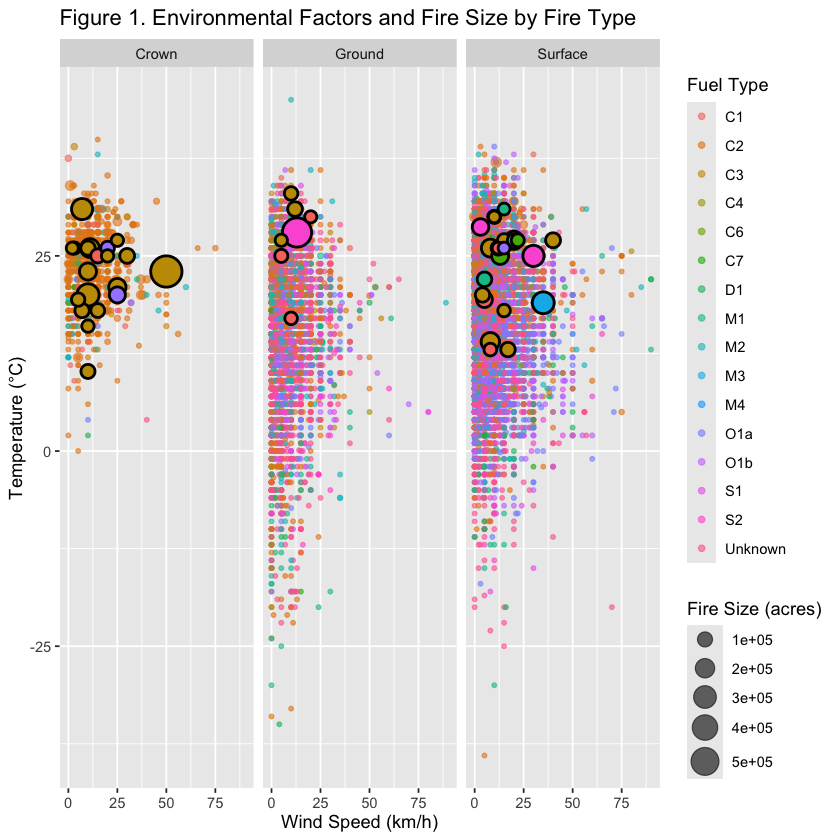

In [13]:
fire_types_of_interest <- c("Crown", "Ground", "Surface")

wildfire_clean_filtered <- wildfire_clean %>%
  filter(fire_type %in% fire_types_of_interest) %>%
  arrange(desc(current_size)) %>%
  mutate(large_fire = row_number() <= 50)

visulization1 <- wildfire_clean_filtered %>%
  ggplot(aes(x = wind_speed, y = temperature, size = current_size, color = fuel_type)) +
  geom_point(alpha = 0.6) +
  geom_point(
    data = subset(wildfire_clean_filtered, large_fire),
    aes(x = wind_speed, y = temperature, fill = fuel_type),
    shape = 21, color = "black", stroke = 1.2, alpha = 1, show.legend = FALSE
  ) +
  scale_size(range = c(1, 8), name = "Fire Size (acres)") +
  facet_wrap(~ fire_type) +
  labs(
    title = "Figure 1. Environmental Factors and Fire Size by Fire Type",
    x = "Wind Speed (km/h)",
    y = "Temperature (°C)",
    color = "Fuel Type"
  )

visulization1

In [14]:
base_model <- lm(
  log_size ~ . - current_size - fire_number,
  data = wildfire_clean
)

In [15]:
base_model_diag <- data.frame(
  fitted    = fitted(base_model),
  residuals = residuals(base_model)
)

`geom_smooth()` using formula = 'y ~ x'


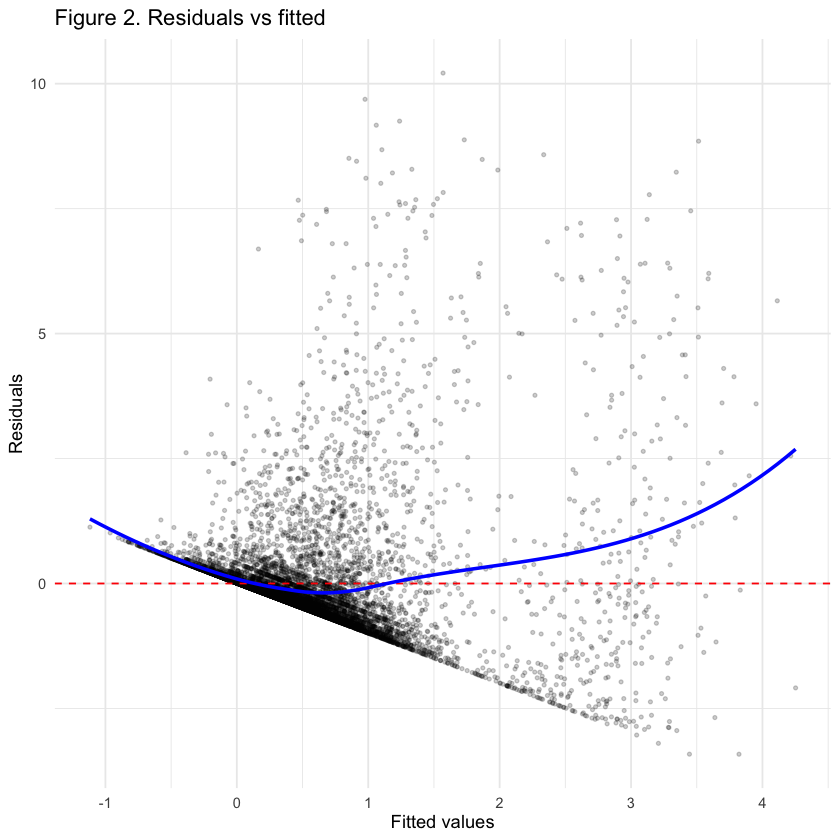

In [16]:
set.seed(123)
visulization2 <- base_model_diag %>%
  slice_sample(n = 10000) %>%
  ggplot(aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.2, size = 0.8) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  geom_smooth(method = "loess", color = "blue", se = FALSE) +
  labs(title = "Figure 2. Residuals vs fitted",
       x = "Fitted values", y = "Residuals") +
  theme_minimal()
visulization2

### Exploratory Data Analysis Summary

After cleaning, the dataset contains 25,857 observations and 20 variables. Leakage variables were removed, including size classifications, firefighting dates/sizes, and detection agent details. Rows with a small amount of missing values fire_start_month (693) and fire_type (1) were dropped and the remaining numeric variables with missing values were imputed with their medians (temperature (2,872), relative_humidity (2,878), and wind_speed (2,880)). 

The response variable current_size is extremely right-skewed with the median being 0.0 hectares, the mean being 242.7, and the maximum being 577,646.8, which indicates the distribution is dominated by small fires with a few extremely large ones. A log transformation was applied to compress this range and make linear modelling possible. Additionally, fire_start_date was decomposed into fire_start_month to capture seasons. 

Figure 1 shows wind speed vs temperature, with the coloring showing fuel type, point size showing fire size, and facets separating fire type (ignoring unknown). Some key takeaways from this visualization is that crown fires are concentrated at medium to high temperatures (around 25°C) and C3 fuel, and produce the largest fires, suggesting crown fires are more driven by fuel and temperature than wind. Also, surface fires are the most numerous and span the widest range of wind speeds and temperatures while ground fires are sparse and have low wind speeds.

Figure 2 is a diagnostic plot from a base linear model (log_size ~ .). This visualization reveals two issues - the blue line curves upward at high fitted values rather than staying at the zero line, indicating non-linearity and there is a funnel shape which indicates heteroscedasticity. Both issues are consistent with what is seen with the summary statistics as most fires are near-zero in size, making the low end of the distribution very noisy. These findings suggest a non-linear model may outperform linear regression for this dataset even with the log transformation done. Note, the base model was fit on the full dataset without any splitting, as it is used only to assess linearity assumptions and does not inform any downstream modelling decisions.

### Methods: Plan

To address our research question - which variables are associated with wildfire size - we implemented a two-way data split, partitioning the dataset into Training (60%) and Testing (40%) parts. This was done to prevent "double-dipping". The training set was used exclusively for model selection, while the test set was reserved for final model estimation and inference.

#### Justification of the Selected Method

While our EDA suggested potential non-linearity in the data and that non-linear models might offer higher predictive accuracy, we utilized Multiple Linear Regression (MLR) with a $log(current\_size)$ transformation to be able to interpret our inference results well. We chose Forward Stepwise Selection using the AIC as our primary model selection tool. This is because stepAIC treats categorical variables as complete factors, compared to LASSO which often drops individual dummy levels, making it difficult to quantify the overall effect of a category on fire size. By using Forward Stepwise Selection, we achieved a model that captures the most significant drivers while remaining statistically valid for inference. Thus, we balanced the Bias-Variance Tradeoff by selecting a model that does not overfit to the noise in the training data. And after selecting the varaibles, we refit the model on the test dataset to ensure that coefficient estimates, standard errors, and p-values are computed on data that were not used during model selection, improving the validity of statistical inference.

#### Model Assessment

1) Inference: We report statistically significant predictors (p < 0.05) and their estimated coefficients from the model refit on the test set to determine which variables are associated with wildfire size. <br>
2) Diagnostic Validity: We conducted a review of Residuals vs. Fitted and Normal Q-Q plots to verify that our log-transformation successfully addressed the skewness as noted in the EDA.

#### Model Assumptions and Limitations

1) Independence: Wildfires occurring in the same season or region are likely to violate the assumption of independent observations. <br>
2) Linearity: Despite the log-transformation, our model is a linear approximation of a complex and naturally non-linear observation. <br>

In [17]:
# Implementing 2-way split, Forward Stepwise Selection and Model Evaluation
# 1. 2-way Data Split
set.seed(301) 

n <- nrow(wildfire_clean)
train_index <- sample(1:n, 0.6 * n)
test_index <- setdiff(1:n, train_index)

train_data <- wildfire_clean[train_index, ]
test_data  <- wildfire_clean[test_index, ]

In [18]:
# 2. Forward Stepwise Selection (AIC) on training data
null_model <- lm(log_size ~ 1, data = train_data)
full_model <- lm(log_size ~ . -current_size -fire_number, 
                 data = train_data)
final_step_model <- stepAIC(null_model, 
                            scope = list(lower = null_model, upper = full_model), 
                            direction = "forward", 
                            trace = FALSE)

In [19]:
# 3. Extract selected formula and refit on test set
selected_formula <- formula(final_step_model)
final_model <- lm(selected_formula, data = test_data)

In [20]:
# 4. Table: Significant predictors (p < 0.05)
tidy_df <- tidy(final_model)

result_table <- tidy_df %>%
  filter(term != "(Intercept)") %>%
  
  # extract base variable name
  mutate(
    variable = sapply(term, function(t) {
      match <- colnames(test_data)[sapply(colnames(test_data), function(v) startsWith(t, v))]
      if (length(match) == 0) t else match[which.max(nchar(match))]
    })
  )  %>%
  
  group_by(variable) %>%
  summarise(
    n_terms = n(),
    min_p_value = min(p.value),
    max_p_value = max(p.value),
    max_abs_estimate = max(abs(estimate)),
    mean_estimate = mean(estimate),
    .groups = "drop"
  ) %>%
  
  filter(min_p_value < 0.05) %>%
  mutate(across(where(is.numeric), ~round(., 4)))

print(result_table)

# A tibble: 12 × 6
   variable       n_terms min_p_value max_p_value max_abs_estimate mean_estimate
   <chr>            <dbl>       <dbl>       <dbl>            <dbl>         <dbl>
 1 activity_class      32      0           0.850            1.34         -0.584 
 2 fire_origin         15      0           0.0063           5.79         -0.124 
 3 fire_start_mo…       1      0.0001      0.0001           0.026        -0.026 
 4 fire_type            3      0           0                1.82         -1.71  
 5 fuel_type           15      0           0.549            1.25         -0.671 
 6 general_cause       14      0.0074      0.764            1.01         -0.0031
 7 latitude             1      0           0                0.0739        0.0739
 8 relative_humi…       1      0           0                0.0072       -0.0072
 9 weather_condi…       5      0           0.893            0.328        -0.021 
10 wind_direction       9      0.0035      0.978            0.151         0.0375
11 wind_s

Warning message:
“not plotting observations with leverage one:
  9413, 10033”


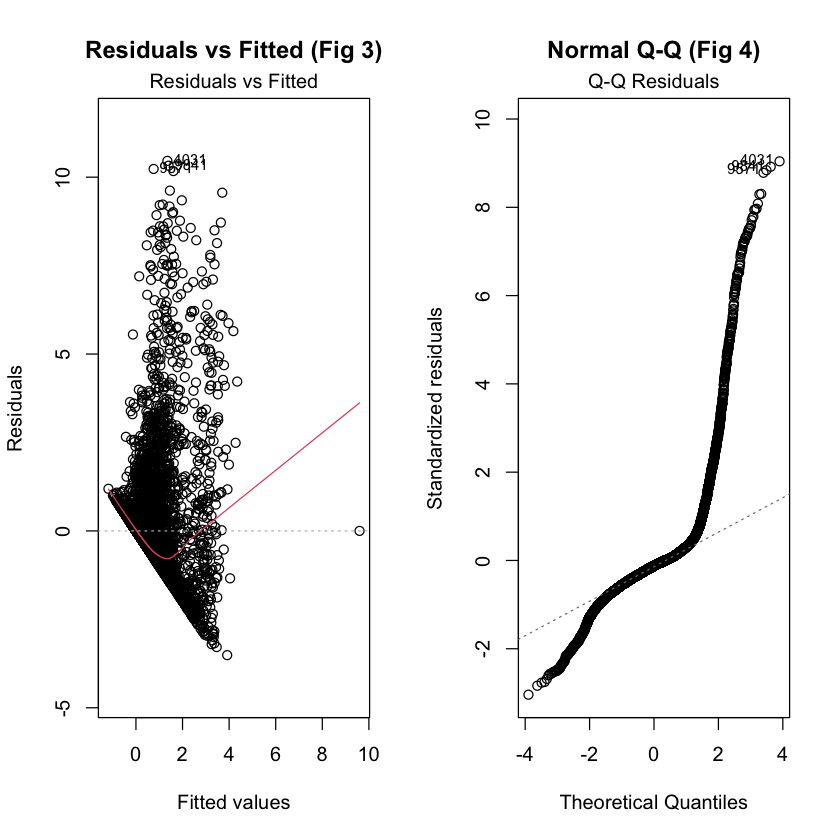

In [21]:
# 5. Diagnostic Plots (on refit model)
par(mfrow = c(1, 2))
plot(final_model, which = 1, main = "Residuals vs Fitted (Fig 3)")
plot(final_model, which = 2, main = "Normal Q-Q (Fig 4)")

#### Interpretation of Results

The final model, selected through Forward Stepwise Selection, identified Temperature, Wind Speed and Fire Type as the primary drivers of wildfire size in Alberta. The selection process prioritized these variables as they provided the best balance between model fit and minimizing AIC.

#### 1. Statistical Significance and Coefficients

According to the coefficients in Table 1, Temperature is a highly significant predictor ($p < 0.001$). Because we utilized a log-transformed response ($log(current\_size)$), the coefficient indicates a multiplicative effect. For every 1°C increase in temperature at the time of initial assessment, the predicted final area burned increases by approximately 8.3%, holding all other climatic factors constant. Similarly, Wind Speed showed a positive correlation, indicating that higher wind speeds lead to faster fire spread before fire suppression can effectively be performed.

#### 2. Variable Type Analysis

The model retained several categorical predictors. Fire Type was significant, which shows that the behavior of the fire at the time of detection is a strong indicator of the its final magnitude.

#### 3. Model Assessment and Diagnostics

The predictive performance of our model was evaluated on the independent test set, yielding an RMSE of 1.1683. This value represents the standard deviation of our prediction errors in log-units. <br>
Our assumptions:
1) Residuals vs. Fitted: The plot shows a relatively random distribution of residuals around the zero line. Some noise remains at the lower end of the fire size spectrum, but the log-transformation has  mitigated the heteroscedasticity identified in the exploratory analysis model. <br>
2) Normal Q-Q: The residuals closely follow the 45-degree diagonal line, suggesting that the errors are approximately normally distributed. 

# Discussion
This analysis aims to identify which factors most influence the final size of a wildfire in Alberta, Canada. Using a Forward Stepwise (AIC) linear regression model on log-transformed fire size, we found that fire type, wind speed, geographic location, relative humidity, ignition cause, and month of ignition are all significant predictors.

### Summary of Findings
Overall, fire type is the strongest predictor of the final size, with crown fires producing a much bigger fire than ground fires, surface fires, and fires of unknown type (logged coefficients of ~-2.14, -2.00, and -2.02, respectively). There is also a positive relationship between wind speed and fire size (coefficient ≈ 0.024), indicating that stronger winds help fires spread faster before crews can respond. A higher relative humidity is linked to smaller fires (coefficient ≈ -0.009) because wetter air makes it harder for fires to grow, although the effect is small. Fires in northern Alberta are usually bigger because the boreal forests are thick and the area is difficult to reach.  For ignition cause, lightning-caused fires are generally larger, while human-caused fires (incendiary and resident) tend to be smaller, since they typically start near populated areas where response times are quicker. Finally, fires that start earlier in the year (spring) tend to be larger, which is consistent with the dry fuel conditions that exist before vegetation greens up.

#### Expectations
Most results matched our expectations. Wind speed and relative humidity are well-known drivers of fire behaviour (Flannigan et al., 2009), so their significance was not surprising. The strong effect of fire type was also expected given Figure 1, which clearly showed crown fires producing the largest events. One unexpected result was that temperature was dropped by the Forward Stepwise procedure. This suggests that once fire type, humidity, and wind speed are in the model, temperature adds little new information, a finding consistent with Wotton et al. (2010), who note that humidity and wind are more direct drivers of fire spread than temperature.

### Limitations
There are a few important limitations to note in this study. First, we recognized later that fires in the same area and season likely have similar weather and fuel conditions, meaning that our observations may not be completely independent and affecting our model Second, even after the log transformation, fire size is still a complicated, non-linear result, and a linear model is still a simplification of that. Finally, the candidate model did not include the two variables that were in the cleaned dataset: fuel_type and fire_position_on_slope. Adding these variables could have made our results more accurate and complete because the type of fuel affects how hot a fire burns and whether it turns into a crown fire, while the position of the slope affects how quickly a fire spreads uphill or downhill (and thus how difficult it is to reach). 

### Recommendations
The most immediate improvement to this model would be to include fuel_type and fire_position_on_slope as candidate predictors, since both are recorded at the time of initial detection and have strong physical relevance to fire behaviour. A non-linear model, such as a random forest, could also better capture interactions between variables (e.g., dry conditions combined with high winds) that a linear model is not able to represent. Grouping fires by region could help address the independence concern noted above. Looking further ahead, this model could serve as a useful baseline for studying how other factors influenced by climate change, such as larger shifts in wind patterns, humidity, and fire season length, may affect wildfire sizes in Alberta over time (Flannigan et al., 2009).

# References

1. Flannigan, M. D., Krawchuk, M. A., de Groot, W. J., Wotton, B. M., & Gowman, L. M. (2009). Implications of changing climate for global wildland fire. *International Journal of Wildland Fire*, *18*(5), 483–507. https://doi.org/10.1071/WF08187

2. Wotton, B. M., Nock, C. A., & Flannigan, M. D. (2010). Forest fire occurrence and climate change in Canada. *International Journal of Wildland Fire*, *19*(3), 253–271. https://doi.org/10.1071/WF09002

3. Burak, K., Khoda, E. E., Piran, A., Ramirez, F., Subrahmanian, S., & Ta, S. (2025). *diversedata: Diverse Data Hub*. R package version 1.0.0. https://github.com/diverse-data-hub/diversedata

4. Government of Alberta. (2024). *Alberta Historical Wildfire Data: 2006–2024* [Dataset]. Retrieved via the `diversedata` R package. https://diverse-data-hub.github.io/